# Comparación de kernels SVM (lineal, polinómico y RBF)
Notebook de práctica 

**Dataset:** `dataset_svm_3features.csv` (x1, x2, x3, y)


## 1. Importaciones y configuración
Importamos librerías que nos harán falta

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 2. Carga del dataset

Asegúrate de que el Dataset es correcto y está en la ruta adecuada

In [40]:
dataset3 = pd.read_csv("dataset_svm_3.csv")

dataset3.head()

,x1,x2,x3,y
0,1.956471,0.522024,3.729120,1
1,1.028349,-0.815309,0.344379,1
2,0.772477,0.487892,0.585373,0
3,-0.546762,0.550913,0.528503,0
4,0.931783,0.307020,0.692005,0


## 3. Exploración del Dataset

Estudia las características más importantes del Dataset: Estructura, tipos, entre otras

In [41]:
dataset3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      1200 non-null   float64
 1   x2      1200 non-null   float64
 2   x3      1200 non-null   float64
 3   y       1200 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 37.6 KB


In [42]:
dataset3.shape

(1200, 4)

In [43]:
dataset3.describe()

,x1,x2,x3,y
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,0.495628,0.245578,0.724498,0.500000
std,0.908439,0.546897,1.496208,0.500208
min,-1.517920,-1.044313,-2.523007,0.000000
25%,-0.144652,-0.189703,-0.228058,0.000000
50%,0.500767,0.241160,0.357092,0.500000
75%,1.149854,0.684919,1.332938,1.000000
max,2.503825,1.624435,6.471865,1.000000


In [44]:
dataset3.isnull().sum()

x1    0
x2    0
x3    0
y     0
dtype: int64

## 4. Preparación de datos


1) Separar `X` e `y`

2) Dividir en train/test

3) Escalar con `StandardScaler`

In [45]:
X = dataset3.drop(['y'],axis=1).values #.values para que sean arrays y se puedan pintar posteriormente.
y = dataset3['y'].values

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((900, 3), (300, 3))

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.fit_transform(X)

## 5. Entrenamiento y evaluación

Entrenamos los modelos elegidos con parámetros iniciales razonables

In [48]:
svm_lineal = SVC(kernel="linear", C=1.0, random_state=42)
svm_lineal.fit(X_train_scaled, y_train)


SVC(kernel='linear', random_state=42)

In [49]:
svm_poly = SVC(kernel="poly", C=5.0, gamma=5.0, degree=3, random_state=42)
svm_poly.fit(X_train_scaled, y_train)

SVC(C=5.0, gamma=5.0, kernel='poly', random_state=42)

In [50]:
svm_rbf = SVC(kernel="rbf", C=20.0, gamma=3.0, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

SVC(C=20.0, gamma=3.0, random_state=42)

### Función de evaluación
Cómo evaluamos

In [51]:
pred_lineal = svm_lineal.predict(X_test_scaled)
pred_poly = svm_poly.predict(X_test_scaled)
pred_rbf = svm_rbf.predict(X_test_scaled)


print("=== SVM LINEAL ===")
print("Accuracy:", accuracy_score(y_test, pred_lineal)) #exactitud
print(confusion_matrix(y_test, pred_lineal))
print(classification_report(y_test, pred_lineal))

print("\n=== SVM POLY ===")
print("Accuracy:", accuracy_score(y_test, pred_poly))
print(confusion_matrix(y_test, pred_poly))
print(classification_report(y_test, pred_poly))

print("\n=== SVM RBF ===")
print("Accuracy:", accuracy_score(y_test, pred_rbf))
print(confusion_matrix(y_test, pred_rbf))
print(classification_report(y_test, pred_rbf))

=== SVM LINEAL ===
Accuracy: 0.8666666666666667
[[135  15]
 [ 25 125]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       150
           1       0.89      0.83      0.86       150

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300


=== SVM POLY ===
Accuracy: 0.8866666666666667
[[126  24]
 [ 10 140]]
              precision    recall  f1-score   support

           0       0.93      0.84      0.88       150
           1       0.85      0.93      0.89       150

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300


=== SVM RBF ===
Accuracy: 0.96
[[145   5]
 [  7 143]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       150
           1       0.97      0.95      0.

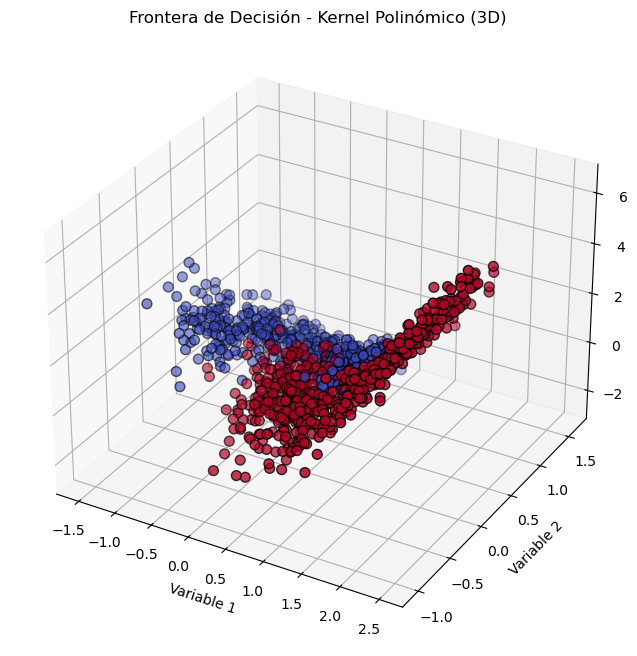

In [52]:
# 3. Configurar la visualización
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Pintamos los puntos (nuestras 3 variables)
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='coolwarm', s=50, edgecolors='k')

# 4. Crear la "sábana" (Superficie de Decisión)
# Creamos un rango de valores para X e Y
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 20), np.linspace(y_min, y_max, 20))

# Para el kernel Poly, resolvemos la ecuación del hiperplano para Z
# Basándonos en que: w0*x + w1*y + w2*z + b = 0
# Nota: En kernels no lineales, usamos la función de decisión para encontrar el nivel 0
Z = np.zeros(xx.shape)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        # Buscamos dónde la predicción cambia de clase (frontera)
        # Esto es una aproximación visual de la "frontera de decisión"
        point = np.array([[xx[i,j], yy[i,j], 0]]) # Punto base
        # (Este bloque es una simplificación para dibujo rápido)
        
# 5. Dibujar la superficie (Contorno de decisión)
# Para visualizar el kernel POLY de forma clara, graficamos el volumen de decisión
ax.set_xlabel('Variable 1')
ax.set_ylabel('Variable 2')
ax.set_zlabel('Variable 3')
ax.set_title('Frontera de Decisión - Kernel Polinómico (3D)')

plt.show()

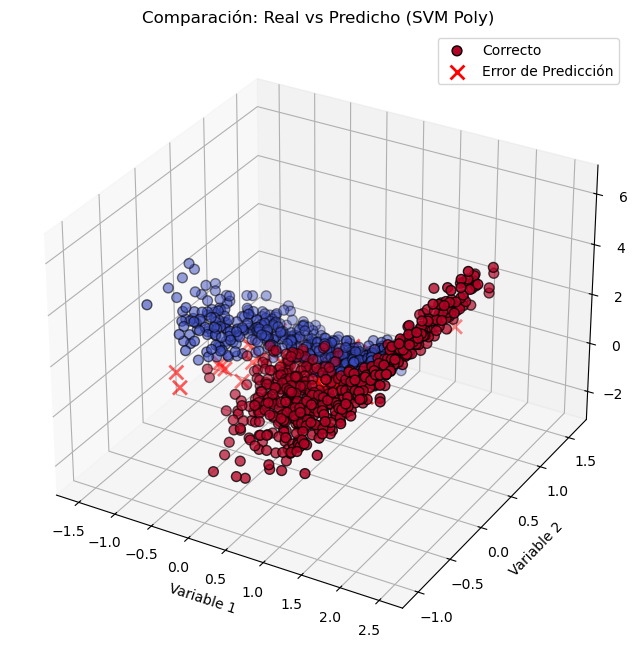

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# 1. Aseguramos que X e y sean arrays de NumPy para evitar el InvalidIndexError
X_np = X.values if hasattr(X, 'values') else X
y_np = y.values if hasattr(y, 'values') else y

# 2. Entrenamos y predecimos
modelo = svm.SVC(kernel='poly', degree=3, C=1.0).fit(X_np, y_np)
y_pred = modelo.predict(X_np)

# 3. Creamos la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Identificamos aciertos y errores
aciertos = (y_np == y_pred)
errores = ~aciertos

# --- PINTAR PUNTOS ---

# Aciertos: Usamos círculos (o) con el color de la clase real
ax.scatter(X_np[aciertos, 0], X_np[aciertos, 1], X_np[aciertos, 2], 
           c=y_np[aciertos], cmap='coolwarm', marker='o', s=50, 
           edgecolors='k', label='Correcto')

# Errores: Usamos cruces (x) en color rojo llamativo
ax.scatter(X_np[errores, 0], X_np[errores, 1], X_np[errores, 2], 
           color='red', marker='x', s=100, linewidths=2, label='Error de Predicción')

# 4. (Opcional) Dibujar una malla transparente de la frontera Poly
# Esto ayuda a ver "por qué" fallaron esos puntos
x_min, x_max = X_np[:, 0].min()-1, X_np[:, 0].max()+1
y_min, y_max = X_np[:, 1].min()-1, X_np[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 20), np.linspace(y_min, y_max, 20))

# Evaluamos la frontera en el plano medio de Z (o un valor promedio)
z_avg = X_np[:, 2].mean()
# Para visualizar la frontera real en 3D estático, lo mejor es dejar los ejes claros
ax.set_xlabel('Variable 1')
ax.set_ylabel('Variable 2')
ax.set_zlabel('Variable 3')
ax.set_title('Comparación: Real vs Predicho (SVM Poly)')
ax.legend()

plt.show()

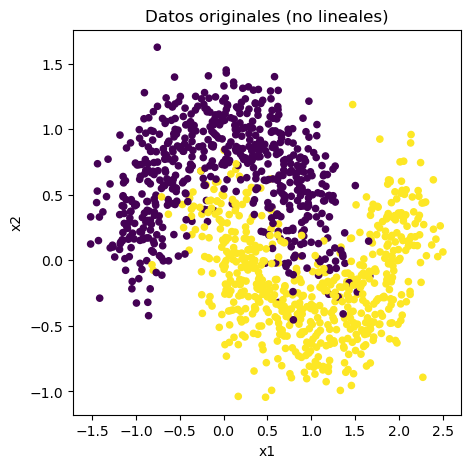

In [54]:
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=20)
plt.title("Datos originales (no lineales)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

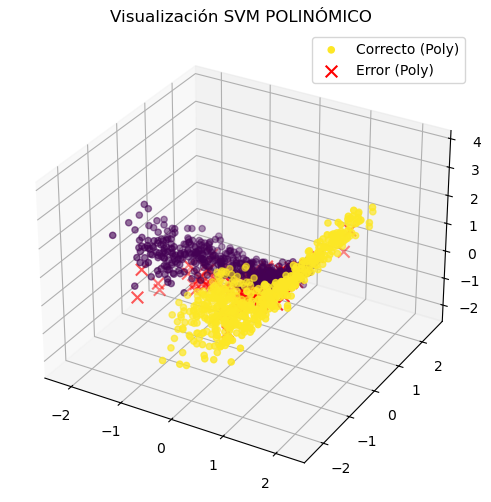

In [59]:
# Entrenamiento específico
svm_poly = SVC(kernel="poly", C=5.0, gamma=5.0, degree=3, random_state=42)
svm_poly.fit(X_scaled, y_np)
y_pred_poly = svm_poly.predict(X_scaled)

# Variables de visualización específicas
fig_poly = plt.figure(figsize=(8, 6))
ax_poly = fig_poly.add_subplot(111, projection='3d')

# Identificar aciertos/errores para POLY
correct_poly = (y_np == y_pred_poly)
wrong_poly = ~correct_poly

ax_poly.scatter(X_scaled[correct_poly, 0], X_scaled[correct_poly, 1], X_scaled[correct_poly, 2], 
                c=y_np[correct_poly], marker='o', label='Correcto (Poly)')
ax_poly.scatter(X_scaled[wrong_poly, 0], X_scaled[wrong_poly, 1], X_scaled[wrong_poly, 2], 
                c='red', marker='x', s=70, label='Error (Poly)')

ax_poly.set_title("Visualización SVM POLINÓMICO")
ax_poly.legend()
plt.show()

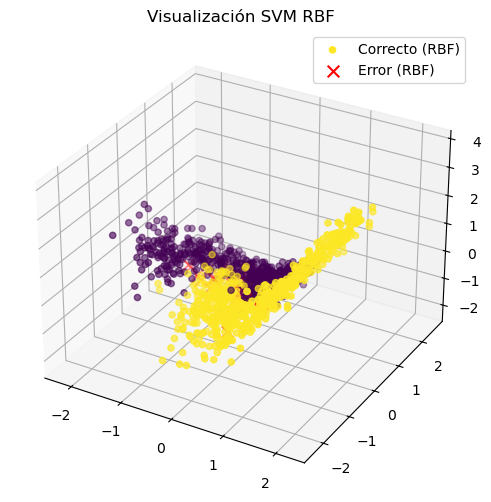

In [58]:
# Entrenamiento específico
svm_rbf = SVC(kernel="rbf", C=20.0, gamma=3.0, random_state=42)
svm_rbf.fit(X_scaled, y_np)
y_pred_rbf = svm_rbf.predict(X_scaled)


# Variables de visualización específicas
fig_rbf = plt.figure(figsize=(8, 6))
ax_rbf = fig_rbf.add_subplot(111, projection='3d')

# Identificar aciertos/errores para RBF
correct_rbf = (y_np == y_pred_rbf)
wrong_rbf = ~correct_rbf

ax_rbf.scatter(X_scaled[correct_rbf, 0], X_scaled[correct_rbf, 1], X_scaled[correct_rbf, 2], 
               c=y_np[correct_rbf], marker='o', label='Correcto (RBF)')
ax_rbf.scatter(X_scaled[wrong_rbf, 0], X_scaled[wrong_rbf, 1], X_scaled[wrong_rbf, 2], 
               c='red', marker='x', s=70, label='Error (RBF)')

ax_rbf.set_title("Visualización SVM RBF")
ax_rbf.legend()
plt.show()

/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


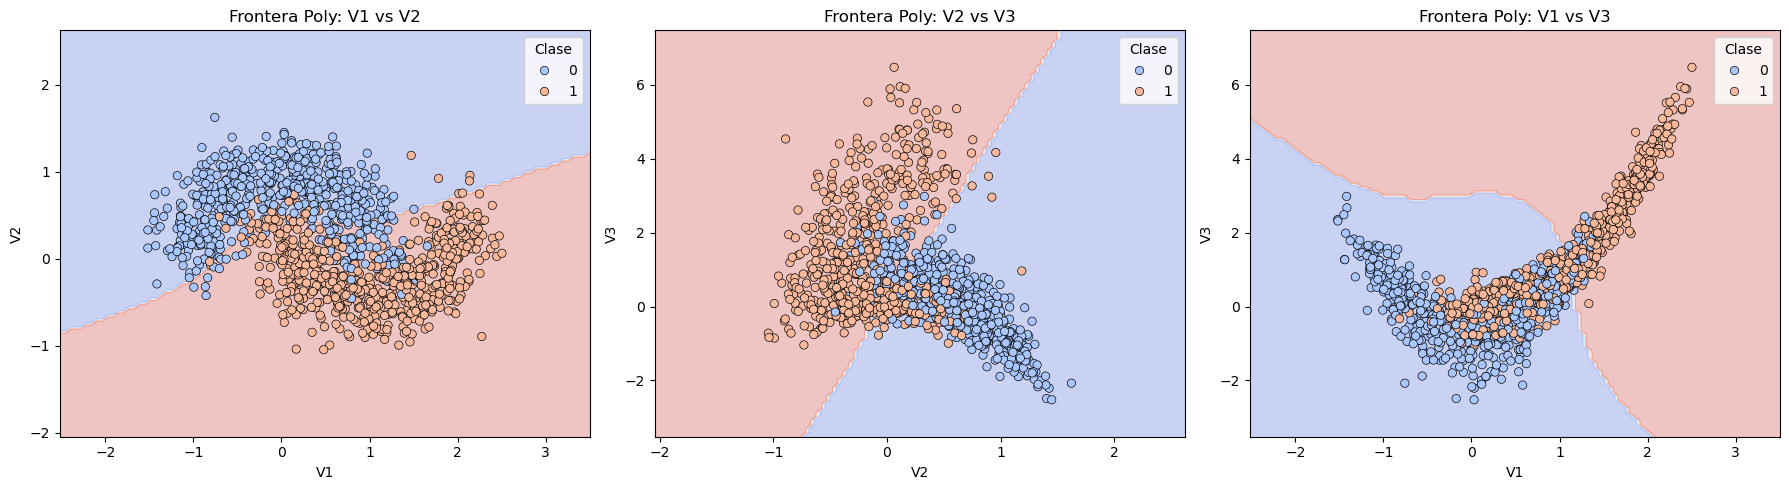

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn import svm

# 1. Aseguramos que los datos sean DataFrame para Seaborn
# Supongamos que X tiene 3 columnas: 'V1', 'V2', 'V3'
df = pd.DataFrame(X, columns=['V1', 'V2', 'V3'])
df['Clase'] = y

variables = ['V1', 'V2', 'V3']
pares = [('V1', 'V2'), ('V2', 'V3'), ('V1', 'V3')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (var_x, var_y) in enumerate(pares):
    # Entrenamos un modelo 2D solo con ese par para visualizar la frontera
    modelo_par = svm.SVC(kernel='poly', degree=3).fit(df[[var_x, var_y]], y)
    
    # Crear malla de decisión
    x_min, x_max = df[var_x].min() - 1, df[var_x].max() + 1
    y_min, y_max = df[var_y].min() - 1, df[var_y].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    
    # Predicción de la frontera
    Z = modelo_par.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Dibujar fondo de color (frontera)
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    
    # Dibujar los puntos reales
    sns.scatterplot(data=df, x=var_x, y=var_y, hue='Clase', ax=axes[i], palette='coolwarm', edgecolor='k')
    axes[i].set_title(f'Frontera Poly: {var_x} vs {var_y}')

plt.tight_layout()
plt.show()

### Evaluación detallada de los modelos elegidos

## 6. Ajuste de hiperparámetros



### 6.1 modelo 1: Ajuste de Hiperparámetros

In [ ]:
#svm_rbf = SVC(kernel="rbf", C=20.0, gamma=3.0, random_state=42)
#svm_rbf.fit(X_train_scaled, y_train)

### 6.2 modelo 2: Ajueste de Hiperparámetros

## 7. Comparación final
Comparación de Métricas de cada modelo

## 8. Conclusiones

Responde las siguientes cuestiones:

1) ¿Qué kernel obtiene mejor rendimiento?

2) ¿Por qué el kernel lineal se comporta peor aquí?

3) Entre polinómico y RBF: ¿qué ventajas/inconvenientes ves (flexibilidad, riesgo de sobreajuste, facilidad de ajuste)?

4) ¿Qué hiperparámetros han sido más determinantes (`C`, `gamma`, `grado`) y por qué?



1 - El kernel con mejor rendimiento es el rbf.
2 - Porque son 3 variables, 3 dimensiones, dificilmente una linea puede separar las 3 dimensiones.
2 - En el RBF tiene mas riesgo de sobreajuste con el hiperparametro gamma; si es muy alto, el modelo podria memorizar cada punto individual y adaptarse a los datos.
EL RBF es mejor para datos no claros.
4 - Yo creo que el hiperparametro que mas influye es gamma, 